In [ ]:
get_ipython().getoutput("pip install --upgrade pip")
get_ipython().getoutput("pip install segmentation-models-pytorch medmnist torchxrayvision")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision import transforms
from tqdm import tqdm
import segmentation_models_pytorch as smp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from medmnist import PneumoniaMNIST
import os
import gc

In [ ]:
import torchxrayvision as xrv
modelo_temp = xrv.autoencoders.ResNetAE(weights="101-elastic")

# Llistem els noms de les capes internes reals
print("Components interns del model:")
for nom, capa in modelo_temp.named_children():
    print(f" - {nom}")

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nihpcrsnamimic_ch-resnet101-2-ae-test2-elastic-e250.pt -O /root/.torchxrayvision/models_data/nihpcrsnamimic_ch-resnet101-2-ae-test2-elastic-e250.pt`
[██████████████████████████████████████████████████]
Components interns del model:
 - conv1
 - bn1
 - relu
 - maxpool
 - layer1
 - layer2
 - layer3
 - layer4
 - uplayer1
 - uplayer2
 - uplayer3
 - uplayer4
 - uplayer_top
 - conv1_1


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import torchxrayvision as xrv

from medmnist import PneumoniaMNIST

# ==============================================================================
# 1. CONFIGURACIÓ GLOBAL
# ==============================================================================
CONFIG = {
    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,
    "ACCUM_STEPS": 2,       # Simula batch de 32
    "LATENT_CHANNELS": 4,   # Latent de 4x28x28
    "EPOCHS_FASE_1": 20,    
    "EPOCHS_FASE_2": 80,    
    "LR_FASE_1": 1e-4,      
    "LR_FASE_2": 1e-5,      
    "VGG_WEIGHT": 0.05,
    "KL_WEIGHT": 0.00025,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "SAVE_DIR": "./artifacts_xrv"
}
os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# ==============================================================================
# 2. EL TURBODATASET (Carrega súper ràpida a GPU)
# ==============================================================================
class TurboDataset(Dataset):
    def __init__(self, data):
        # Normalitzem a 0-1 i pugem directament a la GPU!
        self.images = torch.tensor(data.imgs, dtype=torch.uint8).unsqueeze(1).float().div(255.0).to(CONFIG["DEVICE"])
        self.labels = torch.tensor(data.labels, dtype=torch.long).to(CONFIG["DEVICE"])
    def __len__(self): return len(self.images)
    def __getitem__(self, idx): return self.images[idx], self.labels[idx]

def get_dataloaders():
    print(" Carregant dades de PneumoniaMNIST...")
    data_train = PneumoniaMNIST(split="train", download=True, size=CONFIG["IMG_SIZE"])
    data_val = PneumoniaMNIST(split="val", download=True, size=CONFIG["IMG_SIZE"])
    return {
        'train': DataLoader(TurboDataset(data_train), batch_size=CONFIG["BATCH_SIZE"], shuffle=True),
        'val':   DataLoader(TurboDataset(data_val), batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
    }

loaders = get_dataloaders()
print(f" Dades llestes! {len(loaders['train'].dataset)} imatges de train.")

# ==============================================================================
# 3. VGG PERCEPTUAL LOSS
# ==============================================================================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:16].eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, recon, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
            recon = recon.repeat(1, 3, 1, 1)
        return nn.functional.l1_loss(self.vgg(recon), self.vgg(x))

vgg_loss = VGGPerceptualLoss().to(CONFIG["DEVICE"])

# ==============================================================================
# 4. CLASSES AUXILIARS (Early Stopping)
# ==============================================================================
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, current_loss):
        if self.best_loss is None:
            self.best_loss = current_loss
        elif current_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"  [Early Stopping] Sense millora... Paciència: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = current_loss
            self.counter = 0

# ==============================================================================
# 5. SONDA D'EXPLORACIÓ (TorchXRayVision)
# ==============================================================================
print("\n Llançant una sonda per detectar l'anatomia del model XRV...")
modelo_temp = xrv.autoencoders.ResNetAE(weights="101-elastic")
encoder_sonda = nn.Sequential(
    modelo_temp.conv1, modelo_temp.bn1, modelo_temp.relu, 
    modelo_temp.maxpool, modelo_temp.layer1, modelo_temp.layer2
)

dummy_x = torch.randn(1, 1, 224, 224)
dummy_out = encoder_sonda(dummy_x)
CANALES_XRV = dummy_out.shape[1]
RES_XRV = dummy_out.shape[2]
print(f" Sonda completada. Resolució: {RES_XRV}x{RES_XRV} amb {CANALES_XRV} canals.\n")


# ==============================================================================
# 6. ARQUITECTURA DEL MODEL HÍBRID (DECODER PROFUND 10 PASSES)
# ==============================================================================
class SpatialVAE_XRV(nn.Module):
    def __init__(self, canales_in, latent_channels=4):
        super().__init__()
        experto = xrv.autoencoders.ResNetAE(weights="101-elastic")
        
        self.encoder = nn.Sequential(
            experto.conv1, experto.bn1, experto.relu, 
            experto.maxpool, experto.layer1, experto.layer2
        )
        self.mu_conv = nn.Conv2d(canales_in, latent_channels, 1)       
        self.logvar_conv = nn.Conv2d(canales_in, latent_channels, 1)   
        
        self.decoder_input = nn.Conv2d(latent_channels, canales_in, 1) 
        
        # DECODER DE 10 PASSES: 
        # 3 Upsamples (Transposed) per arribar a 224x224 + 7 Refinaments (Conv2d normals)
        self.decoder = nn.Sequential(
            # --- Bloc 1: Espai 28x28 ---
            nn.Conv2d(canales_in, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True), # 1
            nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),        # 2
            
            # --- Bloc 2: Escalat a 56x56 ---
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True), # 3 (Upsample)
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),           # 4
            
            # --- Bloc 3: Escalat a 112x112 ---
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),  # 5 (Upsample)
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),           # 6
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),           # 7
            
            # --- Bloc 4: Escalat a 224x224 ---
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),  # 8 (Upsample)
            nn.Conv2d(16, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(True),           # 9
            
            # --- Final (Mantingut a 224x224) ---
            nn.Conv2d(16, 1, 3, 1, 1)                                                # 10 (Logits Finals)
            # Recordar que NO hi ha Sigmoid aquí per mantenir la BCEWithLogitsLoss
        )

    def reparameterize(self, mu, log_var):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * log_var)
        return mu

    def forward(self, x):
        features = self.encoder(x)
        mu, log_var = self.mu_conv(features), self.logvar_conv(features)
        log_var = torch.clamp(log_var, -10, 10)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(self.decoder_input(z))
        return recon, mu, log_var


# ==============================================================================
# 7. INICIALITZACIÓ I FUNCIÓ D'ENTRENAMENT
# ==============================================================================
model = SpatialVAE_XRV(canales_in=CANALES_XRV, latent_channels=CONFIG["LATENT_CHANNELS"]).to(CONFIG["DEVICE"])
writer = SummaryWriter(log_dir=f"{CONFIG['SAVE_DIR']}/logs")
scaler = torch.cuda.amp.GradScaler()

def train_epoch(epoch, optimizer, loaders, model, scaler, CONFIG, writer):
    model.train()
    epoch_loss_total = epoch_loss_pixel = epoch_loss_vgg = epoch_loss_kl = 0
    
    optimizer.zero_grad(set_to_none=True) 
    loop = tqdm(loaders['train'], leave=False, desc=f"Epoch {epoch+1}")
    
    for i, (imgs, _) in enumerate(loop):
        # La classe TurboDataset ja puja imgs a la GPU, però ho deixem per seguretat
        imgs = imgs.to(CONFIG["DEVICE"]) 
        

        with torch.cuda.amp.autocast():
            # 1. CANVI Hem de rebre 'recon_logits'
            recon_logits, mu, log_var = model(imgs)
            
            # 2. Pixel Loss amb BCEWithLogitsLoss
            loss_pixel = nn.BCEWithLogitsLoss()(recon_logits, imgs)
            
            # 3. VGG Loss (apliquem el sigmoid aquí perquè la VGG necessita imatges de 0 a 1)
            recon_imgs = torch.sigmoid(recon_logits)
            loss_vgg = vgg_loss(recon_imgs, imgs) * CONFIG["VGG_WEIGHT"]
            
            # 4. KL Divergence (es queda igual)
            loss_kl = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
            
            loss = loss_pixel + loss_vgg + (CONFIG["KL_WEIGHT"] * loss_kl)
            loss = loss / CONFIG["ACCUM_STEPS"]
        
        scaler.scale(loss).backward()
        
        if (i+1) % CONFIG["ACCUM_STEPS"] == 0 or (i+1) == len(loop):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        
        epoch_loss_total += loss.item() * CONFIG["ACCUM_STEPS"]
        epoch_loss_pixel += loss_pixel.item()
        epoch_loss_vgg += loss_vgg.item()
        epoch_loss_kl += loss_kl.item()
        
        loop.set_postfix(Loss=f"{loss.item()*CONFIG['ACCUM_STEPS']:.4f}")
        
    num_batches = len(loaders['train'])
    avg_loss_total = epoch_loss_total / num_batches
    print(f"Ep {epoch+1}: Total={avg_loss_total:.4f} | L1={epoch_loss_pixel/num_batches:.4f} | VGG={epoch_loss_vgg/num_batches:.4f} | KL={epoch_loss_kl/num_batches:.4f}")
    
    writer.add_scalar('Loss/Total', avg_loss_total, epoch)
    writer.add_scalar('Loss/Pixel_BCE', epoch_loss_pixel/num_batches, epoch)
    writer.add_scalar('Loss/VGG_Perceptual', epoch_loss_vgg/num_batches, epoch)
    writer.add_scalar('Loss/KL_Divergence', epoch_loss_kl/num_batches, epoch)
    
    return avg_loss_total

# ==============================================================================
# 8. BUCLE D'ENTRENAMENT BIFÀSIC
# ==============================================================================

# --- FASE 1: CONGELAR ENCODER ---
print(f" INICIANT FASE 1: Congelant Encoder XRV ({CONFIG['EPOCHS_FASE_1']} Epochs)")
for param in model.encoder.parameters():
    param.requires_grad = False

optimizer_f1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["LR_FASE_1"])
early_stopping = EarlyStopping(patience=15, min_delta=0.0001)

for epoch in range(CONFIG["EPOCHS_FASE_1"]):
    avg_loss = train_epoch(epoch, optimizer_f1, loaders, model, scaler, CONFIG, writer)
    
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"{CONFIG['SAVE_DIR']}/vae_xrv_ep{epoch+1}.pth")
        torch.save(model.decoder.state_dict(), f"{CONFIG['SAVE_DIR']}/decoder_xrv_ep{epoch+1}.pth")
    
    early_stopping(avg_loss)
    if early_stopping.early_stop:
        print(" Early Stopping a la Fase 1!")
        break

# --- FASE 2: FINE-TUNING CONJUNT ---
print(f"\n INICIANT FASE 2: Descongelant tot per Fine-Tuning ({CONFIG['EPOCHS_FASE_2']} Epochs)")
for param in model.encoder.parameters():
    param.requires_grad = True

optimizer_f2 = optim.Adam(model.parameters(), lr=CONFIG["LR_FASE_2"])
early_stopping = EarlyStopping(patience=15, min_delta=0.0001) 

for epoch in range(CONFIG["EPOCHS_FASE_1"], CONFIG["EPOCHS_FASE_1"] + CONFIG["EPOCHS_FASE_2"]):
    avg_loss = train_epoch(epoch, optimizer_f2, loaders, model, scaler, CONFIG, writer)
    
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"{CONFIG['SAVE_DIR']}/vae_xrv_ep{epoch+1}.pth")
        torch.save(model.decoder.state_dict(), f"{CONFIG['SAVE_DIR']}/decoder_xrv_ep{epoch+1}.pth")
    
    early_stopping(avg_loss)
    if early_stopping.early_stop:
        print(" Early Stopping a la Fase 2!")
        break

# ==============================================================================
# 9. GUARDAT FINAL I EXTRACCIÓ DE LATENTS
# ==============================================================================
torch.save(model.state_dict(), f"{CONFIG['SAVE_DIR']}/vae_xrv_final.pth")
torch.save(model.decoder.state_dict(), f"{CONFIG['SAVE_DIR']}/decoder_xrv_final.pth")
writer.close()

print("\n Guardant latents")
model.eval()
for split in ['train', 'val']: 
    latents, labels = [], []
    for x, y in tqdm(loaders[split], desc=f"Extraient {split}"):
        with torch.no_grad():
            _, mu, _ = model(x.to(CONFIG["DEVICE"]))
            latents.append(mu.cpu().numpy())
            labels.append(y.cpu().numpy())
    np.save(f"{CONFIG['SAVE_DIR']}/latents_xrv_{split}.npy", np.concatenate(latents))
    np.save(f"{CONFIG['SAVE_DIR']}/labels_xrv_{split}.npy", np.concatenate(labels))
    
print("COMPLETAT AMB ÈXIT!")

2026-03-06 07:56:25.735751: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772783785.899302      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772783785.944550      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772783786.340039      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772783786.340067      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772783786.340070      55 computation_placer.cc:177] computation placer alr

 Carregant dades de PneumoniaMNIST...


100%|██████████| 214M/214M [01:41<00:00, 2.10MB/s] 


 Dades llestes! 4708 imatges de train.
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 240MB/s] 


...

Ep 94: Total=0.6259 | L1=0.6168 | VGG=0.0084 | KL=2.8884
  [Early Stopping] Sense millora... Paciència: 13/15


Ep 95: Total=0.6258 | L1=0.6167 | VGG=0.0084 | KL=2.8901
  [Early Stopping] Sense millora... Paciència: 14/15


Ep 96: Total=0.6259 | L1=0.6168 | VGG=0.0083 | KL=2.8873
  [Early Stopping] Sense millora... Paciència: 15/15
 Early Stopping a la Fase 2!

 Guardant latents


Extraient val: 100%|██████████| 33/33 [00:01<00:00, 18.45it/s]

COMPLETAT AMB ÈXIT!


PLOTS

 Carregant model expert des de /kaggle/input/datasets/sandramrquez/artifacts-xrv/vae_xrv_final.pth...
 Carregant dades de validació...


100%|██████████| 214M/214M [01:04<00:00, 3.32MB/s] 


 Generant comparativa visual...


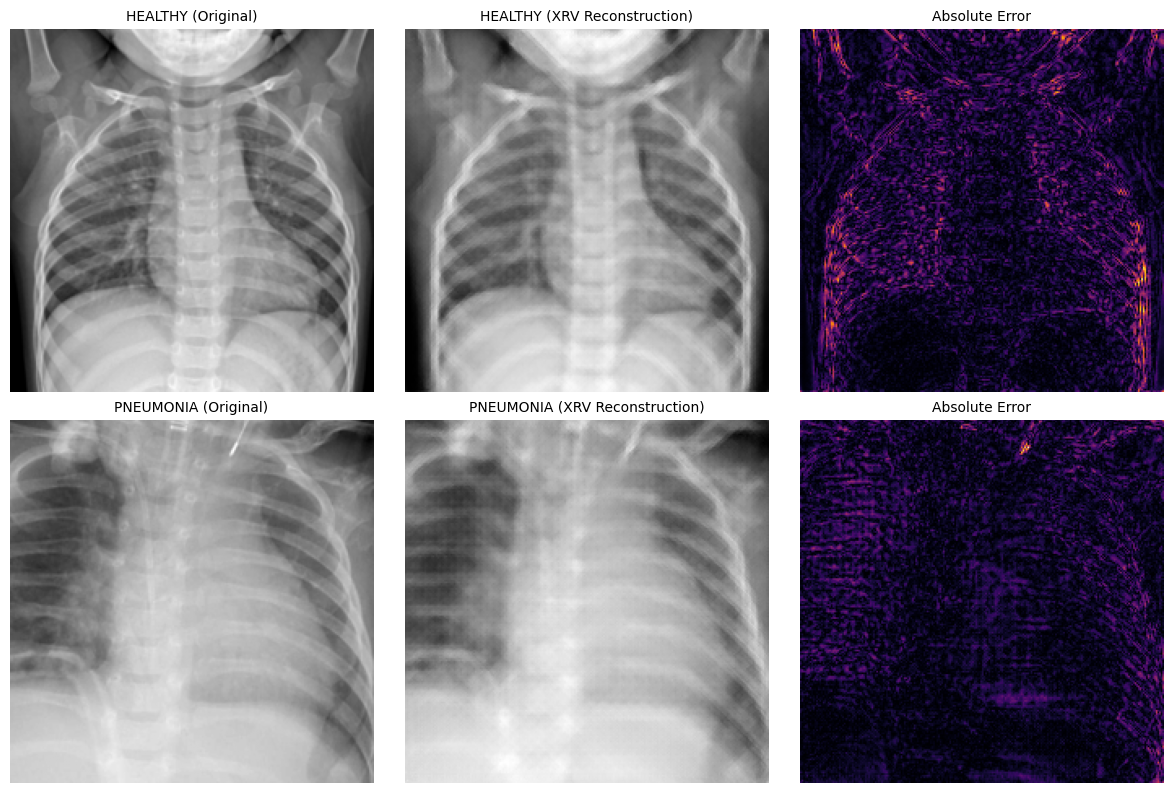

Calculant PCA i Distàncies...


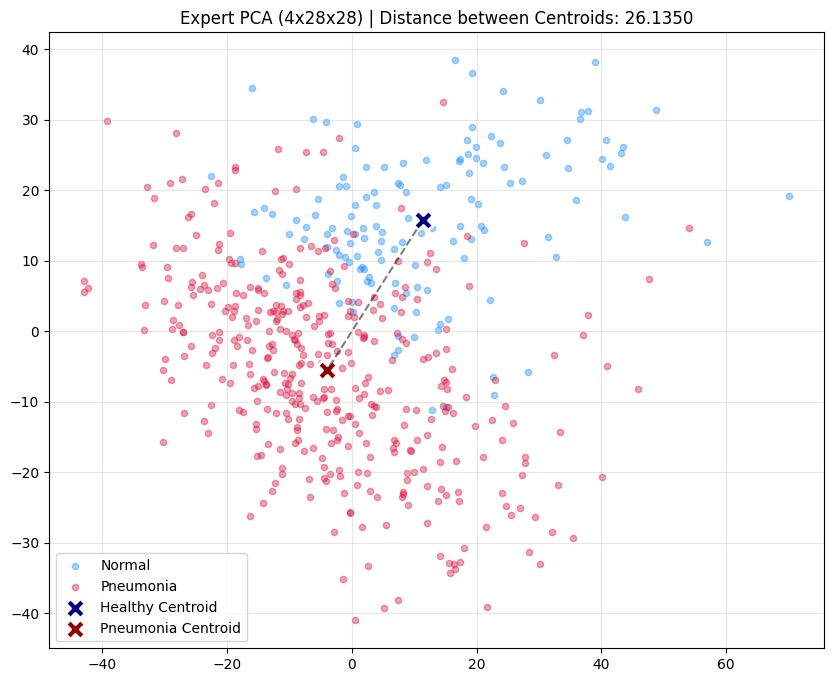


 Latents guardats a: /kaggle/input/datasets/sandramrquez/artifacts-xrv/latents_xrv_train.npy
   Shape original: (4708, 4, 28, 28)
   Duplicats exactes: 18 (de 4708)
   Calculant distàncies knn...

   RESULTATS DE DISTÀNCIA:
   Distància Mitjana entre Veïns: 60.4900 
   Distància Mínima (no zero): 30.8576


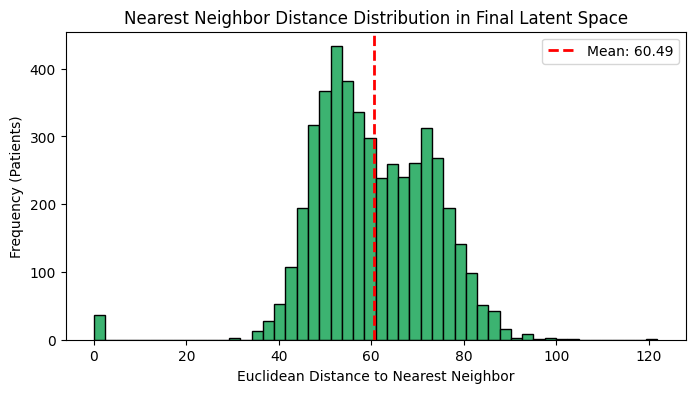

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import os
import torchxrayvision as xrv #El necessitem perquè usem un nou model

# --- 1. CONFIGURACIÓ ---
CONFIG = {
    "IMG_SIZE": 224,
    "BATCH_SIZE": 32,  
    "LATENT_CHANNELS": 4,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "SAVE_DIR": "./artifacts_xrv", 
    "MODEL_PATH": "./artifacts_xrv/vae_xrv_final.pth", # Carreguem el nou model
    "LATENTS_PATH": "./artifacts_xrv/latents_xrv_train.npy" # Carreguem els latents train
}

# --- 2. DEFINICIÓ DEL MODEL (XRV- Expert en Radiografies) ---

class SpatialVAE_XRV(nn.Module):
    def __init__(self, canales_in=512, latent_channels=4):
        super().__init__()
        experto = xrv.autoencoders.ResNetAE(weights="101-elastic")
        
        self.encoder = nn.Sequential(
            experto.conv1, experto.bn1, experto.relu, 
            experto.maxpool, experto.layer1, experto.layer2
        )
        self.mu_conv = nn.Conv2d(canales_in, latent_channels, 1)       
        self.logvar_conv = nn.Conv2d(canales_in, latent_channels, 1)   
        
        self.decoder_input = nn.Conv2d(latent_channels, canales_in, 1) 
        
        # ACTUALITZAT: EL DECODER DE 10 PASSES
        self.decoder = nn.Sequential(
            nn.Conv2d(canales_in, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            
            nn.Conv2d(16, 1, 3, 1, 1)
            # Mantenim sense nn.Sigmoid() aquí perquè és el mateix model que va entrenar
        )

    def forward(self, x):
        features = self.encoder(x)
        mu = self.mu_conv(features)
        
        # A la inferència/plots passem directament el 'mu' al decoder (zero soroll)
        recon = self.decoder(self.decoder_input(mu))
        return recon, mu, None

# --- 3. CARREGAR DADES ---
class TurboDataset(Dataset):
    def __init__(self, data):
        self.images = torch.tensor(data.imgs, dtype=torch.uint8).unsqueeze(1).float().div(255.0).to(CONFIG["DEVICE"])
        self.labels = torch.tensor(data.labels, dtype=torch.long).to(CONFIG["DEVICE"])
    def __len__(self): return len(self.images)
    def __getitem__(self, idx): return self.images[idx], self.labels[idx]

def get_val_loader():
    print(" Carregant dades de validació...")
    data_val = PneumoniaMNIST(split="val", download=True, size=CONFIG["IMG_SIZE"])
    return DataLoader(TurboDataset(data_val), batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

# --- 4. GENERADOR DE GRÀFICS (Plots 1 y 2) ---
def recover_plots():
    if not os.path.exists(CONFIG["MODEL_PATH"]):
        print(f" ERROR: No trobo l'arxiu {CONFIG['MODEL_PATH']}")
        return

    print(f" Carregant model expert des de {CONFIG['MODEL_PATH']}...")
    model = SpatialVAE_XRV(canales_in=512, latent_channels=CONFIG["LATENT_CHANNELS"]).to(CONFIG["DEVICE"])
    state_dict = torch.load(CONFIG["MODEL_PATH"], map_location=CONFIG["DEVICE"])
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    loader = get_val_loader()

    # --- B. Plot de Reconstrucció ---
    print(" Generant comparativa visual...")
    imgs, labels = next(iter(loader))
    imgs = imgs.to(CONFIG["DEVICE"])

    try:
        idx_H = (labels == 0).nonzero(as_tuple=True)[0][0]
        idx_P = (labels == 1).nonzero(as_tuple=True)[0][0]
    except:
        idx_H, idx_P = 0, 1

    with torch.no_grad():

        # 1. Passem les imatges pel model (ara ens retorna logits, no píxels finals)
        rec_H_logits, _, _ = model(imgs[idx_H].unsqueeze(0))
        rec_P_logits, _, _ = model(imgs[idx_P].unsqueeze(0))
        
        # 2. Apliquem el Sigmoid manualment per convertir-ho en imatge visual (0 a 1)
        rec_H = torch.sigmoid(rec_H_logits)
        rec_P = torch.sigmoid(rec_P_logits)

    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    
    def show(ax, img, title, diff=False):
        im = img.cpu().squeeze().numpy()
        cmap = 'inferno' if diff else 'gray'
        ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    show(ax[0,0], imgs[idx_H], "HEALTHY (Original)")
    show(ax[0,1], rec_H, "HEALTHY (XRV Reconstruction)")
    show(ax[0,2], torch.abs(imgs[idx_H]-rec_H), "Absolute Error", diff=True)
    show(ax[1,0], imgs[idx_P], "PNEUMONIA (Original)")
    show(ax[1,1], rec_P, "PNEUMONIA (XRV Reconstruction)")
    show(ax[1,2], torch.abs(imgs[idx_P]-rec_P), "Absolute Error", diff=True)


    plt.tight_layout()
    plt.show()

    # --- C. Plot PCA AMB DISTÀNCIA ---
    print("Calculant PCA i Distàncies...")
    latents, labels_list = [], []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i > 50: break 
            _, mu, _ = model(x)
            latents.append(mu.cpu().view(mu.size(0), -1).numpy())
            labels_list.append(y.cpu().numpy())
    
    X = np.concatenate(latents)
    y = np.concatenate(labels_list).squeeze() 

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    center_H = X_pca[y==0].mean(axis=0)
    center_P = X_pca[y==1].mean(axis=0)
    dist = np.linalg.norm(center_H - center_P)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(X_pca[y==0,0], X_pca[y==0,1], c='dodgerblue', alpha=0.4, label='Normal', s=20)
    plt.scatter(X_pca[y==1,0], X_pca[y==1,1], c='crimson', alpha=0.4, label='Pneumonia', s=20)
    
    plt.scatter(*center_H, c='navy', s=200, marker='X', edgecolors='white', linewidth=2, label='Healthy Centroid')
    plt.scatter(*center_P, c='darkred', s=200, marker='X', edgecolors='white', linewidth=2, label='Pneumonia Centroid')

    plt.plot([center_H[0], center_P[0]], [center_H[1], center_P[1]], 'k--', alpha=0.5)
    

    dist_centers = np.linalg.norm(center_H - center_P)
    # ---------------------------------------------------------

    plt.title(f"Expert PCA (4x28x28) | Distance between Centroids: {dist_centers:.4f}")
    plt.legend()
    plt.legend()


    plt.grid(True, alpha=0.3)
    plt.show()

# --- 5. COMPROVACIO DE DISTANCIES (Plot 3) ---
def check_final_latents(file_path):
    print(f"\n Latents guardats a: {file_path}")
    try:
        data = np.load(file_path)
        data_flat = data.reshape(data.shape[0], -1)
        
        unique_data = np.unique(data_flat, axis=0)
        duplicates = len(data_flat) - len(unique_data)
        
        print(f"   Shape original: {data.shape}")
        print(f"   Duplicats exactes: {duplicates} (de {len(data)})")
        
        print("   Calculant distàncies knn...")
        nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree').fit(data_flat)
        distances, _ = nbrs.kneighbors(data_flat)
        
        nn_dists = distances[:, 1]
        mitjana = np.mean(nn_dists)
        minima = np.min(nn_dists[nn_dists > 0]) if len(nn_dists[nn_dists > 0]) > 0 else 0
        
        print(f"\n   RESULTATS DE DISTÀNCIA:")
        print(f"   Distància Mitjana entre Veïns: {mitjana:.4f} ")
        print(f"   Distància Mínima (no zero): {minima:.4f}")
        
        plt.figure(figsize=(8, 4))
        plt.hist(nn_dists, bins=50, color='mediumseagreen', edgecolor='black')
        plt.axvline(mitjana, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mitjana:.2f}')
        plt.title("Nearest Neighbor Distance Distribution in Final Latent Space") 
        plt.xlabel("Euclidean Distance to Nearest Neighbor")
        plt.ylabel("Frequency (Patients)")
        plt.legend()

    except Exception as e:
        print(f" Error en llegir o processar l'arxiu: {e}")

if __name__ == "__main__":
    recover_plots()
    check_final_latents(CONFIG["LATENTS_PATH"])

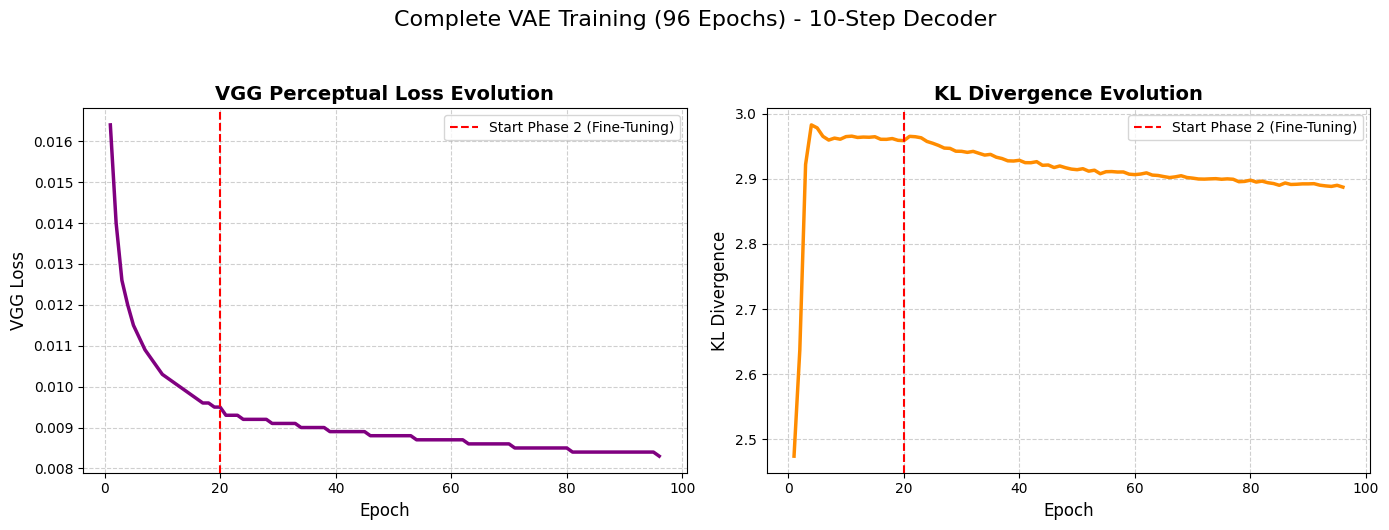

In [ ]:
import matplotlib.pyplot as plt

# Les 96 èpoques completes
epoques = list(range(1, 97))

# Dades extretes del log
vgg_loss = [
    0.0164, 0.0140, 0.0126, 0.0120, 0.0115, 0.0112, 0.0109, 0.0107, 0.0105, 0.0103, 
    0.0102, 0.0101, 0.0100, 0.0099, 0.0098, 0.0097, 0.0096, 0.0096, 0.0095, 0.0095, 
    0.0093, 0.0093, 0.0093, 0.0092, 0.0092, 0.0092, 0.0092, 0.0092, 0.0091, 0.0091, 
    0.0091, 0.0091, 0.0091, 0.0090, 0.0090, 0.0090, 0.0090, 0.0090, 0.0089, 0.0089, 
    0.0089, 0.0089, 0.0089, 0.0089, 0.0089, 0.0088, 0.0088, 0.0088, 0.0088, 0.0088, 
    0.0088, 0.0088, 0.0088, 0.0087, 0.0087, 0.0087, 0.0087, 0.0087, 0.0087, 0.0087, 
    0.0087, 0.0087, 0.0086, 0.0086, 0.0086, 0.0086, 0.0086, 0.0086, 0.0086, 0.0086, 
    0.0085, 0.0085, 0.0085, 0.0085, 0.0085, 0.0085, 0.0085, 0.0085, 0.0085, 0.0085, 
    0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 
    0.0084, 0.0084, 0.0084, 0.0084, 0.0084, 0.0083
]

kl_div = [
    2.4740, 2.6370, 2.9221, 2.9829, 2.9783, 2.9653, 2.9596, 2.9626, 2.9609, 2.9649, 
    2.9656, 2.9636, 2.9642, 2.9639, 2.9647, 2.9608, 2.9607, 2.9619, 2.9592, 2.9587, 
    2.9653, 2.9647, 2.9631, 2.9575, 2.9547, 2.9514, 2.9473, 2.9468, 2.9425, 2.9423, 
    2.9407, 2.9422, 2.9393, 2.9365, 2.9376, 2.9333, 2.9312, 2.9277, 2.9274, 2.9285, 
    2.9249, 2.9248, 2.9264, 2.9208, 2.9213, 2.9174, 2.9198, 2.9171, 2.9150, 2.9141, 
    2.9156, 2.9118, 2.9133, 2.9079, 2.9110, 2.9112, 2.9105, 2.9106, 2.9072, 2.9065, 
    2.9074, 2.9092, 2.9058, 2.9052, 2.9035, 2.9020, 2.9031, 2.9048, 2.9021, 2.9011, 
    2.8998, 2.8996, 2.9000, 2.9003, 2.8994, 2.9000, 2.8994, 2.8956, 2.8961, 2.8980, 
    2.8951, 2.8965, 2.8941, 2.8928, 2.8901, 2.8937, 2.8914, 2.8917, 2.8923, 2.8923, 
    2.8926, 2.8903, 2.8892, 2.8884, 2.8901, 2.8873
]

# Creem la figura amb dos subgràfics horitzontals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gràfica 1: VGG Perceptual Loss ---
ax1.plot(epoques, vgg_loss, color='purple', linewidth=2.5)
ax1.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='Start Phase 2 (Fine-Tuning)')
ax1.set_title("VGG Perceptual Loss Evolution", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("VGG Loss", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- Gràfica 2: Divergència KL ---
ax2.plot(epoques, kl_div, color='darkorange', linewidth=2.5)
ax2.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='Start Phase 2 (Fine-Tuning)')
ax2.set_title("KL Divergence Evolution", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("KL Divergence", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Títol global de la imatge
plt.suptitle("Complete VAE Training (96 Epochs) - 10-Step Decoder", fontsize=16, y=1.05)
plt.tight_layout()

# Guardem la gràfica
plt.savefig("./learning_curve_complete_english.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#######  FULL CODE LOSSES ############

import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

# 1. Llegir l'arxiu de logs que va crear l'entrenament
ruta_logs = './artifacts_xrv/logs'
ea = event_accumulator.EventAccumulator(ruta_logs, size_guidance={'scalars': 0})
ea.Reload()

# 2. Comprovar quines línies tenim guardades
tags = ea.Tags().get('scalars', [])

if not tags:
    print("Encara no s'han guardat dades o la ruta no és correcta.")
else:
    # 3. Dibuixem
    plt.figure(figsize=(10, 6))
    
    for tag in tags:
        esdeveniments = ea.Scalars(tag)
        epochs = [e.step for e in esdeveniments]
        valors = [e.value for e in esdeveniments]
        
        # Canviar el nom perquè es vegi millor a la llegenda
        nom_net = tag.replace('Loss/', '')

        if nom_net == 'Pixel_L1':
            nom_net = 'Pixel_BCE'
        plt.plot(epochs, valors, marker='o', linewidth=2, label=nom_net)
        

        plt.yscale('log')


    plt.title("Training Evolution: Spatial VAE Losses (Log Scale)", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss Value", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Experiment d'interpolació a l'espai latent...


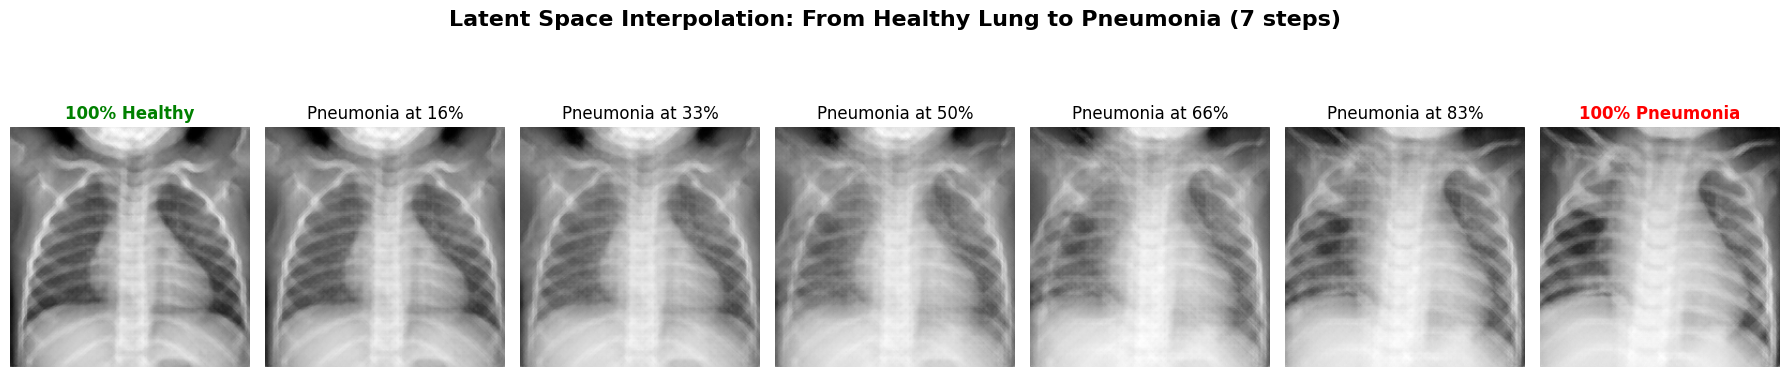

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def interpolacio_latent_lineal(model, ruta_latents, ruta_labels, passos=7):
    print("Experiment d'interpolació a l'espai latent...")
    
    # 1. Carregar les matrius de pacients que acabem de generar
    latents = np.load(ruta_latents)
    labels = np.load(ruta_labels)
    
    # 2. Seleccionar dos pacients (un de sa i un amb pneumònia)
    # Busquem el primer pacient de cada classe
    idx_sa = np.where(labels == 0)[0][0]
    idx_pneumo = np.where(labels == 1)[0][0]
    
    # Extraiem els seus tensors (4 x 28 x 28)
    z_sa = torch.tensor(latents[idx_sa], dtype=torch.float32)
    z_pneumo = torch.tensor(latents[idx_pneumo], dtype=torch.float32)
    
    # Movem els tensors a la mateixa memòria (GPU/CPU) que el model
    device = next(model.parameters()).device
    z_sa = z_sa.to(device)
    z_pneumo = z_pneumo.to(device)
    
    # 3. Crear els passos d'interpolació (matemàtica Lerp)
    # Generem els percentatges de mescla (de 0.0 a 1.0)
    alphas = np.linspace(0, 1, passos)
    
    z_interpolats = []
    for alpha in alphas:
        # Fórmula: (1 - alpha) * A + (alpha) * B
        z_mix = (1.0 - alpha) * z_sa + alpha * z_pneumo
        z_interpolats.append(z_mix)
        
    # Apilem tots els tensors per passar-los de cop pel Decoder
    z_batch = torch.stack(z_interpolats)
    
    # 4. Generar les imatges amb el Decoder

    model.eval()
    with torch.no_grad():
        # 1. Expandim els 4 canals a 512 fent servir la capa adaptadora del model
        z_projectat = model.decoder_input(z_batch)
        
        # 2. Passem per la seqüència principal del decoder
        logits_reconstruïts = model.decoder(z_projectat)
        
        # 3. CRÍTIC: Com que ara fem servir BCEWithLogits, hem d'aplicar el Sigmoid
        # per transformar els números crus en imatges de 0 a 1
        imatges_finals = torch.sigmoid(logits_reconstruïts).cpu().numpy()
        
    # 5. Dibuixar la transició
    
    fig, axes = plt.subplots(1, passos, figsize=(18, 4))
    fig.suptitle(f"Latent Space Interpolation: From Healthy Lung to Pneumonia ({passos} steps)", fontsize=16, fontweight='bold', y=1.05)
    
    for i, ax in enumerate(axes):
        ax.imshow(imatges_finals[i, 0], cmap='gray')
        ax.axis('off')
        
        if i == 0:
            ax.set_title("100% Healthy", color='green', fontweight='bold')
        elif i == passos - 1:
            ax.set_title("100% Pneumonia", color='red', fontweight='bold')
        else:
            ax.set_title(f"Pneumonia at {int(alphas[i]*100)}%")

    plt.tight_layout()
    
    plt.savefig(f"{CONFIG['SAVE_DIR']}/interpolacio_v11_bce_xrv.png", dpi=300, bbox_inches='tight')
    
    plt.show()


# --- 1. CONSTRUIR I CARREGAR EL MODEL ---
# Instanciem el model buit (ha d'estar definida a dalt)
model = SpatialVAE_XRV(canales_in=512, latent_channels=4).to(CONFIG["DEVICE"])

# Carreguem els pesos des de la ruta on tinguem el Dataset o arxiu pujat
model.load_state_dict(torch.load(CONFIG["MODEL_PATH"], map_location=CONFIG["DEVICE"]))

model.eval() 


# --- 2. EXECUTAR LA INTERPOLACIÓ ---
# Assegurar-se que les rutes coincideixin amb el CONFIG["SAVE_DIR"] (o la ruta del Dataset)
ruta_l = "./artifacts_xrv/latents_xrv_train.npy"
ruta_y = "./artifacts_xrv/labels_xrv_train.npy"


# Cridem la funció passant-hi el 'model' que ja està en memòria
interpolacio_latent_lineal(model, ruta_l, ruta_y, passos=7)



In [ ]:
import shutil
# Comprimeix tota la carpeta (pesos, latents i logs) en un sol arxiu ZIP
shutil.make_archive('artifacts_v11_steps10dec_xrv_final', 'zip', './artifacts_xrv')